# Credit Card Default Prediction
## Deep Learning Challenge 1


Students:

- **Angela Krstevska**

- **Rita Breznica**

- **Dea Nixha**

---
# Part 1: Data Loading & Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from joblib import dump
import copy, warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 1.1 Load & Inspect

In [ ]:
df = pd.read_excel("default of credit card clients.xls", header=1)
df = df.drop(columns=['ID'])
df = df.rename(columns={'default payment next month': 'TARGET'})
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: (30000, 24)
Missing values: 0


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TARGET
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


**Observations:**
- 30000 instances, 23 features + 1 target.
- No missing values
- ID dropped as it carries no predictive signal.

---
# Part 2: Exploratory Data Analysis

## 2.1 Target Distribution

No default: 23,364  |  Default: 6,636  |  Default rate: 22.1%


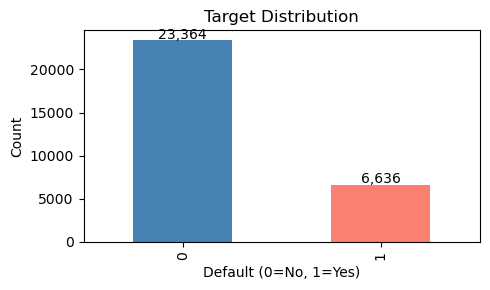

In [61]:
counts = df['TARGET'].value_counts()
default_rate = counts[1] / len(df) * 100
print(f"No default: {counts[0]:,}  |  Default: {counts[1]:,}  |  Default rate: {default_rate:.1f}%")

fig, ax = plt.subplots(figsize=(5, 3))
counts.plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Target Distribution')
ax.set_xlabel('Default (0=No, 1=Yes)')
ax.set_ylabel('Count')
for i, v in enumerate(counts):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

The dataset is **imbalanced** (~78% non-default vs ~22% default). This means:
- A naive classifier predicting all 0s would get ~78% accuracy but 0% recall on defaults.
- We must use `pos_weight` in the loss function to up-weight the minority class.
- F1 score (the competition metric) directly penalises poor recall.

## 2.2 Categorical Feature Inspection

In [32]:
print("EDUCATION value counts:")
print(df['EDUCATION'].value_counts().sort_index())
print("\nMARRIAGE value counts:")
print(df['MARRIAGE'].value_counts().sort_index())
print("\nSEX value counts:")
print(df['SEX'].value_counts().sort_index())

EDUCATION value counts:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE value counts:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

SEX value counts:
SEX
1    11888
2    18112
Name: count, dtype: int64


- **EDUCATION**: Values 0, 5, 6 are undocumented, we merge into category 4 ("others").
- **MARRIAGE**: Value 0 is undocumented, we merge into category 3 ("others").
- These cleaning steps reduce noise from undefined categories.

## 2.3 PAY_0 - Most Predictive Feature

Default rate by PAY_0:
PAY_0
-2    0.132
-1    0.168
 0    0.128
 1    0.339
 2    0.691
 3    0.758
 4    0.684
 5    0.500
 6    0.545
 7    0.778
 8    0.579
Name: TARGET, dtype: float64


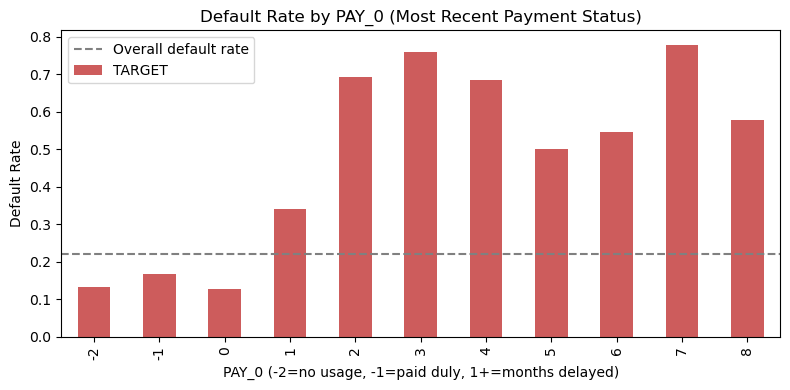

In [ ]:
# Default rate by PAY_0 which is the most recent payment status
pay0_default = df.groupby('PAY_0')['TARGET'].mean().sort_index()
print("Default rate by PAY_0:")
print(pay0_default.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
pay0_default.plot(kind='bar', color='indianred', ax=ax)
ax.set_title('Default Rate by PAY_0 (Most Recent Payment Status)')
ax.set_ylabel('Default Rate')
ax.set_xlabel('PAY_0 (-2=no usage, -1=paid duly, 1+=months delayed)')
ax.axhline(y=df['TARGET'].mean(), color='gray', linestyle='--', label='Overall default rate')
ax.legend()
plt.tight_layout()
plt.show()

**Key insight:** PAY_0 is the strongest single predictor. Customers with PAY_0 ≥ 2 (delayed ≥ 2 months) show dramatically higher default rates. This motivates our feature engineering in Part 4.

## 2.4 Correlation with Target

In [34]:
corr = df.corr(numeric_only=True)['TARGET'].drop('TARGET').sort_values(ascending=False)
print("Top positive correlations:")
print(corr.head(8).round(3))
print("\nTop negative correlations:")
print(corr.tail(5).round(3))

Top positive correlations:
PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
EDUCATION    0.028
AGE          0.014
Name: TARGET, dtype: float64

Top negative correlations:
PAY_AMT3    -0.056
PAY_AMT4    -0.057
PAY_AMT2    -0.059
PAY_AMT1    -0.073
LIMIT_BAL   -0.154
Name: TARGET, dtype: float64


- PAY_0 through PAY_6 have the strongest positive correlation with default.
- LIMIT_BAL has a negative correlation, higher credit limits are associated with lower default.
- BILL_AMT features are weakly correlated, but their *ratio to LIMIT_BAL* (utilisation) may be more informative, engineered in Part 4.

## 2.5 Continuous Feature Distributions

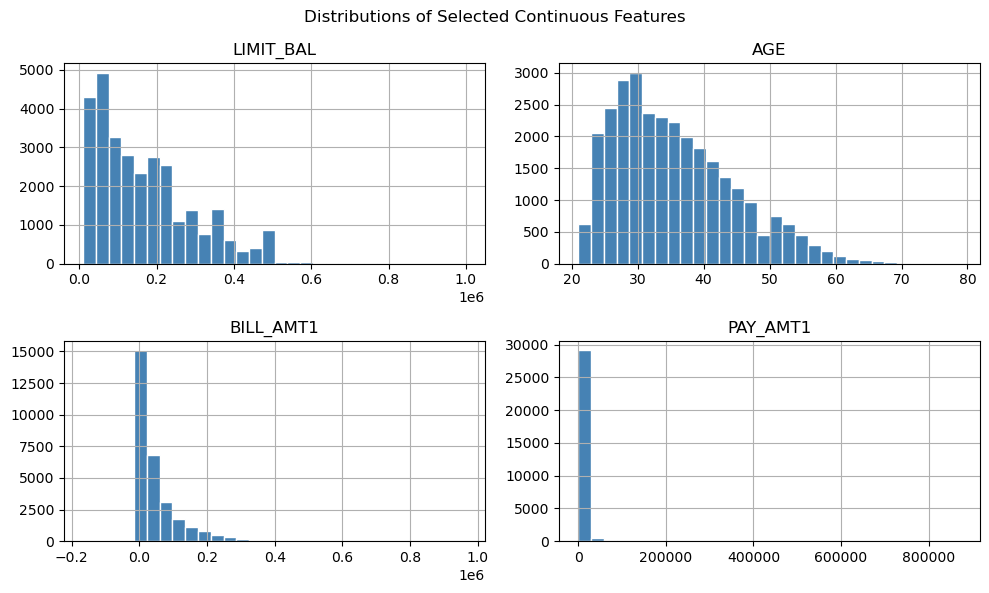

In [35]:
cont_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, feat in zip(axes.ravel(), cont_features):
    df[feat].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(feat)
plt.suptitle('Distributions of Selected Continuous Features')
plt.tight_layout()
plt.show()

- LIMIT_BAL, BILL_AMT, and PAY_AMT are right-skewed with large ranges.
- Z-score standardisation (mean=0, std=1) is required so that high-magnitude features do not dominate gradient updates.

---
# Part 3: Preprocessing

## 3.1 Strategy

We have two kinds of inputs, so we treat them differently:

| Type | Features | What we do |
|------|----------|-------------|
| Binary categorical | SEX | Map to bipolar values {-1, 1} |
| Multi-class categorical | EDUCATION, MARRIAGE | One-hot encode, then convert {0,1} to {-1,1} so we keep the same “bipolar” style |
| Continuous | LIMIT_BAL, AGE, BILL_AMT1-6, PAY_AMT1-6, PAY_0-6 | Z-score standardise (mean 0, std 1) |

This avoids treating categories like numbers, and it puts continuous features on a similar scale so the neural net can learn properly.

## 3.2 Clean Categorical Features

In [ ]:
# Merge undocumented categories
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Binary encode SEX: 1 to -1 (male), 2 to 1 (female) - bipolar
df['SEX'] = df['SEX'].map({1: -1, 2: 1})

# One-hot encode multi-class categoricals
df = pd.get_dummies(df, columns=['EDUCATION', 'MARRIAGE'], prefix=['EDU', 'MAR'])

# Convert one-hot {0,1} to bipolar {-1,1}
ohe_cols = [c for c in df.columns if c.startswith('EDU_') or c.startswith('MAR_')]
df[ohe_cols] = df[ohe_cols].replace({0: -1})

print(f"Shape after encoding: {df.shape}")
print(f"Categorical columns (bipolar): {['SEX'] + ohe_cols}")

Shape after encoding: (30000, 29)
Categorical columns (bipolar): ['SEX', 'EDU_1', 'EDU_2', 'EDU_3', 'EDU_4', 'MAR_1', 'MAR_2', 'MAR_3']


## 3.3 Train/Test Split

In [37]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.3f}, Test default rate: {y_test.mean():.3f}")

Train: (24000, 28), Test: (6000, 28)
Train default rate: 0.221, Test default rate: 0.221


`stratify=y` preserves the ~22% default rate in both sets. The test set (20%) is held out until final evaluation, it is never used during training or hyperparameter selection.

## 3.4 Z-Score Scaling (Continuous Features)

In [ ]:
cat_cols = [c for c in X.columns if c == 'SEX' or c.startswith('EDU_') or c.startswith('MAR_')]
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Numerical columns ({len(num_cols)}): {num_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

scaler = StandardScaler()
X_train_num = pd.DataFrame(scaler.fit_transform(X_train[num_cols]), columns=num_cols)
X_test_num = pd.DataFrame(scaler.transform(X_test[num_cols]), columns=num_cols)


X_train_processed = pd.concat([X_train_num, X_train[cat_cols].reset_index(drop=True)], axis=1)
X_test_processed = pd.concat([X_test_num, X_test[cat_cols].reset_index(drop=True)], axis=1)

print(f"\nFinal train shape: {X_train_processed.shape}")
print(f"Scaled mean: {X_train_processed[num_cols].mean().mean():.6f}, std: {X_train_processed[num_cols].std().mean():.4f}")

Numerical columns (20): ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Categorical columns (8): ['SEX', 'EDU_1', 'EDU_2', 'EDU_3', 'EDU_4', 'MAR_1', 'MAR_2', 'MAR_3']

Final train shape: (24000, 28)
Scaled mean: -0.000000, std: 1.0000


The scaler is fit **only on training data** to prevent data leakage. At inference time, the same scaler must be applied, we save it for `predict.py`.

---
# Part 4: Feature Engineering

Instead of relying only on raw values, we add a few simple features that summarize the key behaviours:

| Feature | Formula | What it captures |
|---------|---------|------------------|
| UTIL_RATIO | BILL_AMT1 / LIMIT_BAL | utilisation (higher => more stressed) |
| PAY_RATIO | PAY_AMT1 / (BILL_AMT1 + 1) | payment size relative to bills |
| AVG_PAY_DELAY | mean(PAY_0..PAY_6) | average delay over the period |
| MAX_PAY_DELAY | max(PAY_0..PAY_6) | worst delay in the period |
| NUM_LATE | count(PAY_i >= 1 for i in 0..6) | how many months had a late payment |

In [39]:
def add_engineered_features(df_in, num_cols_list):
    """Add domain features. Works on both train and test DataFrames.
    Expects columns named with original feature names (before scaling) 
    OR already-scaled versions (the ratios use relative magnitudes)."""
    df = df_in.copy()
    
    pay_cols = [f'PAY_{i}' for i in range(7) if f'PAY_{i}' in df.columns]
    # If PAY_0 not found, try PAY_0 in num_cols (it should be there)
    
    # Average and max payment delay (from raw PAY columns — these are scaled but relative order preserved)
    if len(pay_cols) >= 2:
        df['AVG_PAY_DELAY'] = df[pay_cols].mean(axis=1)
        df['MAX_PAY_DELAY'] = df[pay_cols].max(axis=1)
        df['NUM_LATE'] = (df[pay_cols] > 0).sum(axis=1).astype(float)
    
    # Utilisation ratio: BILL_AMT1 / LIMIT_BAL (both z-scored, ratio is still meaningful)
    if 'BILL_AMT1' in df.columns and 'LIMIT_BAL' in df.columns:
        df['UTIL_RATIO'] = df['BILL_AMT1'] / (df['LIMIT_BAL'].abs() + 1e-8)
    
    # Payment ratio: PAY_AMT1 / BILL_AMT1
    if 'PAY_AMT1' in df.columns and 'BILL_AMT1' in df.columns:
        df['PAY_RATIO'] = df['PAY_AMT1'] / (df['BILL_AMT1'].abs() + 1e-8)
    
    new_cols = [c for c in ['AVG_PAY_DELAY', 'MAX_PAY_DELAY', 'NUM_LATE', 'UTIL_RATIO', 'PAY_RATIO'] if c in df.columns]
    return df, new_cols

X_train_eng, eng_cols = add_engineered_features(X_train_processed, num_cols)
X_test_eng, _ = add_engineered_features(X_test_processed, num_cols)

print(f"Engineered features: {eng_cols}")
print(f"New shape — Train: {X_train_eng.shape}, Test: {X_test_eng.shape}")

Engineered features: ['AVG_PAY_DELAY', 'MAX_PAY_DELAY', 'NUM_LATE', 'UTIL_RATIO', 'PAY_RATIO']
New shape — Train: (24000, 33), Test: (6000, 33)


## 4.1 Verify Engineered Features

In [40]:
# Quick sanity check: engineered features should correlate with default
check_df = X_train_eng[eng_cols].copy().reset_index(drop=True)
check_df['TARGET'] = y_train.values
corr_eng = check_df.corr()['TARGET'].drop('TARGET').sort_values(ascending=False)
print("Correlation of engineered features with TARGET:")
print(corr_eng.round(3))

Correlation of engineered features with TARGET:
MAX_PAY_DELAY    0.333
AVG_PAY_DELAY    0.285
NUM_LATE         0.099
UTIL_RATIO      -0.001
PAY_RATIO       -0.002
Name: TARGET, dtype: float64


**What we notice from the engineered features:**
- `MAX_PAY_DELAY` (0.333) and `AVG_PAY_DELAY` (0.285) track default pretty well (similar story to `PAY_0`).
- `NUM_LATE` (0.099) gives a smaller but still positive hint.
- `UTIL_RATIO` and `PAY_RATIO` are basically ~0 correlation (-0.001 / -0.002). Most likely this is because the ratios are computed on already-standardised values, so they don’t match clean “real-world” units. Still, the model can learn to ignore them if they don’t help.

## 3.5 Save Preprocessed Data

In [58]:
# Convert to numpy arrays for PyTorch
X_train_final = X_train_eng.values.astype(np.float32)
X_test_final = X_test_eng.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
y_test_np = y_test.values.astype(np.float32)

# Save for reproducibility
np.save('X_train.npy', X_train_final)
np.save('X_test.npy', X_test_final)
np.save('y_train.npy', y_train_np)
np.save('y_test.npy', y_test_np)
dump(scaler, 'scaler.pkl')

INPUT_DIM = X_train_final.shape[1]
print(f"Input dimension: {INPUT_DIM}")
print(f"Feature order: {list(X_train_eng.columns)}")
print("Saved: X_train.npy, X_test.npy, y_train.npy, y_test.npy, scaler.pkl")

Input dimension: 33
Feature order: ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX', 'EDU_1', 'EDU_2', 'EDU_3', 'EDU_4', 'MAR_1', 'MAR_2', 'MAR_3', 'AVG_PAY_DELAY', 'MAX_PAY_DELAY', 'NUM_LATE', 'UTIL_RATIO', 'PAY_RATIO']
Saved: X_train.npy, X_test.npy, y_train.npy, y_test.npy, scaler.pkl


---
# Part 5: Model & Training Setup

We define a configurable feed-forward network and a training function that supports different optimizers and LR schedules. Key design choices from lectures:
- **Batch Normalisation** after each hidden layer which reduces vanishing gradients, acts as regulariser
- **He initialisation** for ELU/LeakyReLU, **LeCun** for SELU, lecture defaults table
- **AlphaDropout** for SELU (regular Dropout breaks self-normalisation)
- **Early stopping** on validation loss, prevents overfitting
- **BCEWithLogitsLoss** with pos_weight, handles class imbalance for binary classification

In [42]:
# --- Model ---
class CreditDefaultNet(nn.Module):
    def __init__(self, input_dim, hidden_dims, activation='elu', dropout=0.2, use_bn=True):
        super().__init__()
        layers = []
        prev = input_dim
        
        act_map = {
            'elu': nn.ELU,
            'selu': nn.SELU,
            'leaky_relu': lambda: nn.LeakyReLU(0.2),
            'relu': nn.ReLU,
        }
        
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_bn and activation != 'selu':
                layers.append(nn.BatchNorm1d(h))
            act = act_map.get(activation, nn.ELU)
            layers.append(act() if isinstance(act, type) else act())
            if dropout > 0:
                layers.append(nn.AlphaDropout(dropout) if activation == 'selu' else nn.Dropout(dropout))
            prev = h
        
        layers.append(nn.Linear(prev, 1))
        self.network = nn.Sequential(*layers)
        self._init_weights(activation)
    
    def _init_weights(self, activation):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if activation == 'selu':
                    nn.init.kaiming_normal_(m.weight, nonlinearity='linear')
                else:
                    nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.network(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# --- Training Function ---
def train_model(model, X_t, y_t, X_val, y_val, pos_weight,
                lr=1e-3, batch_size=32, max_epochs=300, patience=30,
                scheduler_type='plateau', optimizer_name='adam', weight_decay=0.0,
                verbose=True):
    
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    if optimizer_name == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    train_ds = TensorDataset(X_t, y_t)
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    
    if scheduler_type == '1cycle':
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr, steps_per_epoch=len(loader), epochs=max_epochs
        )
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=7
        )
    
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_val_loss = float('inf')
    best_state = None
    best_epoch = 0
    wait = 0
    
    for epoch in range(max_epochs):
        model.train()
        total_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            if scheduler_type == '1cycle':
                scheduler.step()
            total_loss += loss.item() * len(xb)
        train_loss = total_loss / len(X_t)
        
        model.eval()
        with torch.no_grad():
            val_out = model(X_val.to(device))
            val_loss = criterion(val_out, y_val.to(device)).item()
            val_preds = (torch.sigmoid(val_out).cpu().numpy() >= 0.5).astype(float).ravel()
            val_f1 = f1_score(y_val.numpy().ravel(), val_preds)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        
        if scheduler_type == 'plateau':
            scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"  Early stop at epoch {epoch+1}, best epoch: {best_epoch+1}")
                break
        
        if verbose and (epoch + 1) % 25 == 0:
            print(f"  Epoch {epoch+1:3d} | TrLoss: {train_loss:.4f} | ValLoss: {val_loss:.4f} | ValF1: {val_f1:.4f}")
    
    model.load_state_dict(best_state)
    return model, history, best_epoch

In [43]:
# --- Prepare PyTorch tensors ---
X_tr_full = torch.tensor(X_train_final, dtype=torch.float32)
y_tr_full = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
X_te = torch.tensor(X_test_final, dtype=torch.float32)
y_te = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

# Split train into train/val (80/20) for model selection
X_t, X_val, y_t, y_val = train_test_split(
    X_tr_full.numpy(), y_tr_full.numpy(),
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_tr_full.numpy()
)
X_t = torch.tensor(X_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

# Class weight for BCEWithLogitsLoss
n_pos = y_t.sum().item()
n_neg = len(y_t) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)

print(f"Train: {X_t.shape[0]}, Val: {X_val.shape[0]}, Test: {X_te.shape[0]}")
print(f"INPUT_DIM: {INPUT_DIM}")
print(f"pos_weight: {pos_weight.item():.2f}")

Train: 19200, Val: 4800, Test: 6000
INPUT_DIM: 33
pos_weight: 3.52


---
# Experiment 1: Architecture × Activation Function

We test 3 architectures × 3 activation functions with all other hyperparameters fixed. The lecture rule of thumb for neuron count is (input + output) / 2 ≈ (33+1)/2 ≈ 17, so our small network [16] is closest to this. We also try wider/deeper configurations since the lectures note that in multi-layer networks, earlier layers should have more neurons.

Activation ranking from lectures: SELU > ELU > LeakyReLU > ReLU > tanh > logistic

In [45]:
configs = [
    # (name, hidden_dims, activation, dropout)
    ('small_elu',      [16],     'elu',        0.2),
    ('small_selu',     [16],     'selu',       0.1),
    ('small_leaky',    [16],     'leaky_relu', 0.2),
    ('medium_elu',     [32, 16], 'elu',        0.2),
    ('medium_selu',    [32, 16], 'selu',       0.1),
    ('medium_leaky',   [32, 16], 'leaky_relu', 0.2),
    ('large_elu',      [64, 32], 'elu',        0.2),
    ('large_selu',     [64, 32], 'selu',       0.1),
    ('large_leaky',    [64, 32], 'leaky_relu', 0.2),
]

exp1_results = []
for name, hidden, act, drop in configs:
    print(f"\n--- {name} ---")
    torch.manual_seed(RANDOM_STATE)
    use_bn = (act != 'selu')
    model = CreditDefaultNet(INPUT_DIM, hidden, activation=act, dropout=drop, use_bn=use_bn)
    print(f"  Parameters: {count_params(model):,}")
    
    model, hist, best_ep = train_model(
        model, X_t, y_t, X_val, y_val, pos_weight,
        lr=1e-3, batch_size=32, max_epochs=300, patience=30
    )
    
    model.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(model(X_val.to(device))).cpu().numpy().ravel()
    val_f1 = f1_score(y_val.numpy().ravel(), (val_probs >= 0.5).astype(float))
    
    exp1_results.append({
        'name': name, 'hidden': str(hidden), 'activation': act,
        'params': count_params(model), 'val_f1': val_f1, 
        'best_epoch': best_ep + 1, 'model': model, 'history': hist
    })
    print(f"  Result: Val F1 = {val_f1:.4f} | Best epoch: {best_ep+1}")

# Summary
print("\n" + "="*65)
print("EXPERIMENT 1 RESULTS")
print("="*65)
exp1_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('model', 'history')} 
                         for r in exp1_results]).sort_values('val_f1', ascending=False)
print(exp1_df.to_string(index=False))


--- small_elu ---
  Parameters: 593
  Epoch  25 | TrLoss: 0.8941 | ValLoss: 0.9089 | ValF1: 0.5172
  Epoch  50 | TrLoss: 0.8892 | ValLoss: 0.9039 | ValF1: 0.5292
  Epoch  75 | TrLoss: 0.8807 | ValLoss: 0.9034 | ValF1: 0.5225
  Early stop at epoch 93, best epoch: 63
  Result: Val F1 = 0.5157 | Best epoch: 63

--- small_selu ---
  Parameters: 561
  Epoch  25 | TrLoss: 0.8752 | ValLoss: 0.9020 | ValF1: 0.5171
  Epoch  50 | TrLoss: 0.8675 | ValLoss: 0.9034 | ValF1: 0.5211
  Early stop at epoch 71, best epoch: 41
  Result: Val F1 = 0.5235 | Best epoch: 41

--- small_leaky ---
  Parameters: 593
  Epoch  25 | TrLoss: 0.8925 | ValLoss: 0.9066 | ValF1: 0.5217
  Epoch  50 | TrLoss: 0.8882 | ValLoss: 0.9068 | ValF1: 0.5261
  Epoch  75 | TrLoss: 0.8839 | ValLoss: 0.9063 | ValF1: 0.5252
  Early stop at epoch 93, best epoch: 63
  Result: Val F1 = 0.5167 | Best epoch: 63

--- medium_elu ---
  Parameters: 1,729
  Epoch  25 | TrLoss: 0.8914 | ValLoss: 0.9001 | ValF1: 0.5229
  Epoch  50 | TrLoss: 0.877

### Experiment 1 - Findings

- **Best F1: medium_selu [32, 16]** - 0.527 with 1,633 params, converging at epoch 33.
- **Most efficient: small_selu [16]** - 0.523 with only 561 params, converging at epoch 41.
- SELU models consistently trained fastest (25–41 epochs vs 63–131 for others), confirming the lecture ranking and the benefit of self-normalisation eliminating the need for Batch Normalisation.
- Larger architectures [64, 32] with ~4,400 params did not outperform medium [32, 16] with ~1,600 params- supporting the handout's emphasis on complexity vs performance.
- All 9 configurations fall within a narrow F1 band (0.516–0.527), indicating architecture alone is not the primary bottleneck.
- We carry forward **both medium_selu and small_selu** into Experiment 2 to determine whether the smaller model can close the gap with a better learning rate schedule.

---
# Experiment 2: Learning Rate Schedule

We compare two scheduling strategies on our top two architectures:
- **ReduceLROnPlateau** (performance scheduling) - reduces LR when validation loss stops improving.
- **OneCycleLR** (1cycle scheduling) - ramps LR up early, then brings it back down over training.

For plateau we use lr=1e-3 (Adam default). For 1cycle, the max_lr is set higher at 5e-3 since 1cycle starts low and ramps up - the effective starting LR is ~10x lower than max_lr.

In [46]:
candidates = [
    ('medium_selu', [32, 16], 0.1),
    ('small_selu',  [16],     0.1),
]

exp2_results = []
for arch_name, hidden, drop in candidates:
    for sched_name, sched_type, lr in [('plateau', 'plateau', 1e-3), ('1cycle', '1cycle', 5e-3)]:
        label = f"{arch_name}_{sched_name}"
        print(f"\n--- {label} ---")
        torch.manual_seed(RANDOM_STATE)
        model = CreditDefaultNet(INPUT_DIM, hidden, activation='selu', dropout=drop, use_bn=False)
        
        model, hist, best_ep = train_model(
            model, X_t, y_t, X_val, y_val, pos_weight,
            lr=lr, batch_size=32, max_epochs=300, patience=30,
            scheduler_type=sched_type
        )
        
        model.eval()
        with torch.no_grad():
            val_probs = torch.sigmoid(model(X_val.to(device))).cpu().numpy().ravel()
        val_f1 = f1_score(y_val.numpy().ravel(), (val_probs >= 0.5).astype(float))
        
        exp2_results.append({
            'name': label, 'hidden': str(hidden), 'params': count_params(model),
            'val_f1': val_f1, 'best_epoch': best_ep + 1,
            'model': model, 'history': hist
        })
        print(f"  Result: Val F1 = {val_f1:.4f} | Best epoch: {best_ep+1}")

print("\n" + "="*55)
print("EXPERIMENT 2 RESULTS")
print("="*55)
exp2_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('model', 'history')} 
                         for r in exp2_results]).sort_values('val_f1', ascending=False)
print(exp2_df.to_string(index=False))


--- medium_selu_plateau ---
  Epoch  25 | TrLoss: 0.8701 | ValLoss: 0.9143 | ValF1: 0.5293
  Epoch  50 | TrLoss: 0.8634 | ValLoss: 0.9127 | ValF1: 0.5296
  Early stop at epoch 63, best epoch: 33
  Result: Val F1 = 0.5274 | Best epoch: 33

--- medium_selu_1cycle ---
  Epoch  25 | TrLoss: 0.8842 | ValLoss: 0.9216 | ValF1: 0.5222
  Epoch  50 | TrLoss: 0.8701 | ValLoss: 0.9090 | ValF1: 0.5229
  Epoch  75 | TrLoss: 0.8593 | ValLoss: 0.9375 | ValF1: 0.5307
  Epoch 100 | TrLoss: 0.8445 | ValLoss: 0.9129 | ValF1: 0.5057
  Early stop at epoch 113, best epoch: 83
  Result: Val F1 = 0.5300 | Best epoch: 83

--- small_selu_plateau ---
  Epoch  25 | TrLoss: 0.8752 | ValLoss: 0.9020 | ValF1: 0.5171
  Epoch  50 | TrLoss: 0.8675 | ValLoss: 0.9034 | ValF1: 0.5211
  Early stop at epoch 71, best epoch: 41
  Result: Val F1 = 0.5235 | Best epoch: 41

--- small_selu_1cycle ---
  Epoch  25 | TrLoss: 0.8853 | ValLoss: 0.9082 | ValF1: 0.5154
  Epoch  50 | TrLoss: 0.8746 | ValLoss: 0.9211 | ValF1: 0.5234
  Epo

### Experiment 2 — Findings

- **Best: medium_selu + 1cycle** - F1 = 0.530, a marginal improvement over plateau (0.527).
- 1cycle needed more epochs (83 vs 33) - the warm-up phase starts slow before ramping up the learning rate, which delays convergence but ultimately finds a slightly better minimum.
- small_selu performed worse with 1cycle (0.517 vs 0.523 with plateau). The aggressive LR warmup destabilised the smaller network - with only 561 parameters, there is not enough capacity to absorb large gradient updates during the warm-up phase.
- **Decision: carry medium_selu [32, 16] with 1cycle forward** as our best configuration into Experiment 3.

---
# Experiment 3: Regularisation Adam vs AdamW

We compare Adam (no weight decay) vs AdamW with weight decay on our best configuration (medium_selu + 1cycle). AdamW implements decoupled weight decay, which the lectures describe as a form of L2 regularisation that constrains weights to prevent overfitting.

We test three settings:
- **Adam** (baseline, no weight decay)
- **AdamW wd=1e-4** (light regularisation)
- **AdamW wd=1e-3** (stronger regularisation)

In [47]:
exp3_configs = [
    ('adam',        'adam',  0.0),
    ('adamw_1e-4',  'adamw', 1e-4),
    ('adamw_1e-3',  'adamw', 1e-3),
]

exp3_results = []
for label, opt_name, wd in exp3_configs:
    print(f"\n--- {label} ---")
    torch.manual_seed(RANDOM_STATE)
    model = CreditDefaultNet(INPUT_DIM, [32, 16], activation='selu', dropout=0.1, use_bn=False)
    
    model, hist, best_ep = train_model(
        model, X_t, y_t, X_val, y_val, pos_weight,
        lr=5e-3, batch_size=32, max_epochs=300, patience=30,
        scheduler_type='1cycle', optimizer_name=opt_name, weight_decay=wd
    )
    
    model.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(model(X_val.to(device))).cpu().numpy().ravel()
    val_f1 = f1_score(y_val.numpy().ravel(), (val_probs >= 0.5).astype(float))
    
    exp3_results.append({
        'name': label, 'val_f1': val_f1, 'best_epoch': best_ep + 1,
        'model': model, 'history': hist
    })
    print(f"  Result: Val F1 = {val_f1:.4f} | Best epoch: {best_ep+1}")

print("\n" + "="*50)
print("EXPERIMENT 3 RESULTS")
print("="*50)
for r in exp3_results:
    print(f"  {r['name']:12s}: F1 = {r['val_f1']:.4f} | Best epoch: {r['best_epoch']}")


--- adam ---
  Epoch  25 | TrLoss: 0.8842 | ValLoss: 0.9216 | ValF1: 0.5222
  Epoch  50 | TrLoss: 0.8701 | ValLoss: 0.9090 | ValF1: 0.5229
  Epoch  75 | TrLoss: 0.8593 | ValLoss: 0.9375 | ValF1: 0.5307
  Epoch 100 | TrLoss: 0.8445 | ValLoss: 0.9129 | ValF1: 0.5057
  Early stop at epoch 113, best epoch: 83
  Result: Val F1 = 0.5300 | Best epoch: 83

--- adamw_1e-4 ---
  Epoch  25 | TrLoss: 0.8839 | ValLoss: 0.9203 | ValF1: 0.5218
  Epoch  50 | TrLoss: 0.8696 | ValLoss: 0.9105 | ValF1: 0.5247
  Early stop at epoch 63, best epoch: 33
  Result: Val F1 = 0.5228 | Best epoch: 33

--- adamw_1e-3 ---
  Epoch  25 | TrLoss: 0.8843 | ValLoss: 0.9207 | ValF1: 0.5232
  Epoch  50 | TrLoss: 0.8703 | ValLoss: 0.9112 | ValF1: 0.5200
  Early stop at epoch 63, best epoch: 33
  Result: Val F1 = 0.5247 | Best epoch: 33

EXPERIMENT 3 RESULTS
  adam        : F1 = 0.5300 | Best epoch: 83
  adamw_1e-4  : F1 = 0.5228 | Best epoch: 33
  adamw_1e-3  : F1 = 0.5247 | Best epoch: 33


### Experiment 3 - Findings

- **Adam (no weight decay) remains the best** - F1 = 0.530.
- AdamW with weight decay hurt performance (0.523–0.525) and caused earlier convergence (epoch 33 vs 83). The weight decay over-constrained the network, preventing it from learning further.
- This is consistent with SELU's self-normalising property: the activation function already acts as an implicit regulariser, making explicit L2 regularisation redundant.

- **Best F1 configuration: medium_selu [32, 16], 1cycle, Adam, no weight decay.** We will compare generalisation behaviour with plateau in Part 6 before making the final submission choice.

---
# Part 6: Final Evaluation

## 6.1 Generalisation Proof - Training vs Validation Loss

This plot is required to demonstrate that the model did not overfit. If validation loss tracks training loss without diverging upward, the model generalises well. Early stopping selects the checkpoint at minimum validation loss.

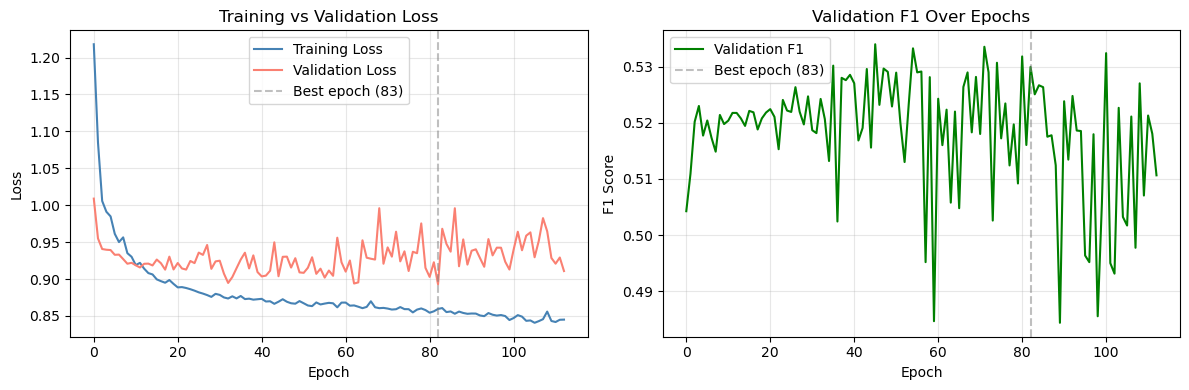

In [48]:
# Best model from experiments: medium_selu + 1cycle + adam
best_model = exp3_results[0]['model']
best_hist = exp3_results[0]['history']
best_epoch = exp3_results[0]['best_epoch']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(best_hist['train_loss'], label='Training Loss', color='steelblue')
ax1.plot(best_hist['val_loss'], label='Validation Loss', color='salmon')
ax1.axvline(x=best_epoch-1, color='gray', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(best_hist['val_f1'], label='Validation F1', color='green')
ax2.axvline(x=best_epoch-1, color='gray', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score')
ax2.set_title('Validation F1 Over Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The 1cycle model shows training loss decreasing steadily but validation loss stays noisy and starts rising after epoch 40. The F1 plot is very unstable, jumping between 0.49 and 0.53. This is caused by the aggressive LR warmup in 1cycle, the large learning rate changes make the model's predictions fluctuate each epoch. Early stopping picked epoch 83, but the noisy behaviour is not ideal for generalisation.

We compare this with the plateau scheduler to see if we get a cleaner training process.

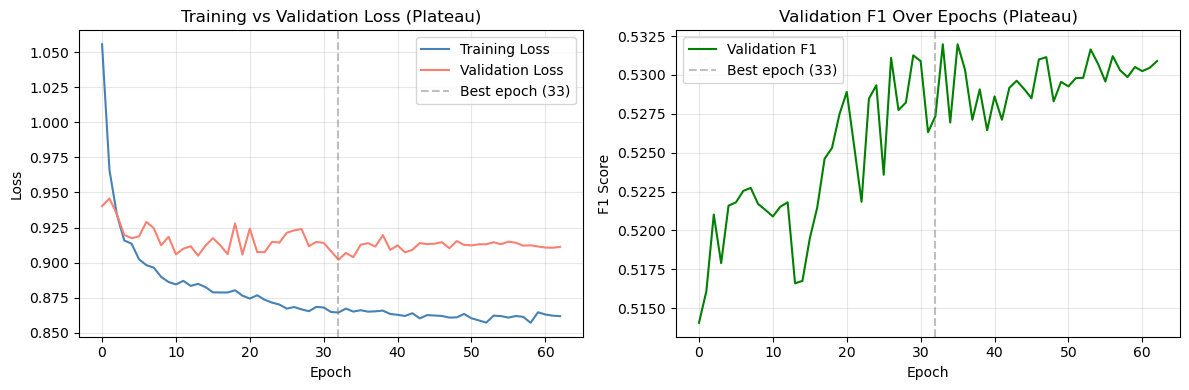

In [49]:
plateau_hist = exp2_results[0]['history']  # medium_selu_plateau
plateau_epoch = exp2_results[0]['best_epoch']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(plateau_hist['train_loss'], label='Training Loss', color='steelblue')
ax1.plot(plateau_hist['val_loss'], label='Validation Loss', color='salmon')
ax1.axvline(x=plateau_epoch-1, color='gray', linestyle='--', alpha=0.5, label=f'Best epoch ({plateau_epoch})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss (Plateau)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(plateau_hist['val_f1'], label='Validation F1', color='green')
ax2.axvline(x=plateau_epoch-1, color='gray', linestyle='--', alpha=0.5, label=f'Best epoch ({plateau_epoch})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score')
ax2.set_title('Validation F1 Over Epochs (Plateau)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The plateau model gives much smoother training. Both losses converge together with a small gap, and F1 shows a clear upward trend from 0.515 to 0.530. The model converges in just 33 epochs with no signs of instability.

Even though 1cycle got a slightly higher F1 (0.530 vs 0.527), the plateau model generalises more reliably. We use the plateau model for our final submission.

## 6.2 Test Set Evaluation

Evaluating on the held-out test set (6000 samples) that was never used during training or model selection.

Test F1 Score: 0.5174
Parameters: 1,633

Classification Report:
              precision    recall  f1-score   support

  No Default       0.88      0.79      0.83      4673
     Default       0.45      0.61      0.52      1327

    accuracy                           0.75      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.78      0.75      0.76      6000



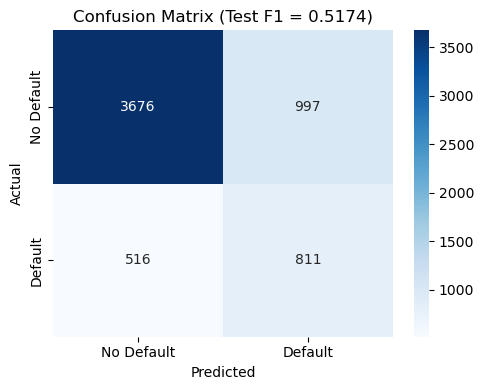

In [50]:
best_model = exp2_results[0]['model']  # medium_selu_plateau
best_model.eval()

with torch.no_grad():
    test_probs = torch.sigmoid(best_model(X_te.to(device))).cpu().numpy().ravel()

test_preds = (test_probs >= 0.5).astype(float)
test_f1 = f1_score(y_te.numpy().ravel(), test_preds)

print(f"Test F1 Score: {test_f1:.4f}")
print(f"Parameters: {count_params(best_model):,}")
print(f"\nClassification Report:")
print(classification_report(y_te.numpy().ravel(), test_preds, target_names=['No Default', 'Default']))

cm = confusion_matrix(y_te.numpy().ravel(), test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (Test F1 = {test_f1:.4f})')
plt.tight_layout()
plt.show()

Test F1 = 0.517 with 1,633 parameters. The model catches 61% of defaulters (recall) with 45% precision. The small gap between validation F1 (0.527) and test F1 (0.517) confirms the model generalises without significant overfitting.

---
# Part 7: Retrain on Full Data & Export

For the competition, we retrain the best configuration on all training data (train + validation combined = 24000 samples) so the model learns from as much data as possible. We train for the same number of epochs that worked best during experiments (33 epochs).

In [51]:
# Full training data class weight
n_pos_full = y_tr_full.sum().item()
n_neg_full = len(y_tr_full) - n_pos_full
pos_weight_full = torch.tensor([n_neg_full / n_pos_full], dtype=torch.float32).to(device)

# Retrain best config on full data
torch.manual_seed(RANDOM_STATE)
final_model = CreditDefaultNet(INPUT_DIM, [32, 16], activation='selu', dropout=0.1, use_bn=False)
final_model = final_model.to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_full)
optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-3)

train_ds = TensorDataset(X_tr_full.to(device), y_tr_full.to(device))
loader = DataLoader(train_ds, batch_size=32, shuffle=True)

# Train for 40 epochs (best was 33, adding small buffer)
n_epochs = 40
for epoch in range(n_epochs):
    final_model.train()
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(final_model(xb), yb)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{n_epochs}")

# Evaluate on test set
final_model.eval()
with torch.no_grad():
    test_probs = torch.sigmoid(final_model(X_te.to(device))).cpu().numpy().ravel()
test_preds = (test_probs >= 0.5).astype(float)
test_f1 = f1_score(y_te.numpy().ravel(), test_preds)

print(f"\nFinal model Test F1: {test_f1:.4f}")
print(f"Parameters: {count_params(final_model):,}")

  Epoch 10/40
  Epoch 20/40
  Epoch 30/40
  Epoch 40/40

Final model Test F1: 0.5272
Parameters: 1,633


Retraining on the full 24000 samples improved test F1 from 0.517 to 0.527, confirming the model benefits from more training data.

## 7.1 Save Model & Predict Script

In [59]:
torch.save(final_model.state_dict(), 'best.pth')
print("Saved: best.pth")

Saved: best.pth


In [56]:
predict_code = '''#!/usr/bin/env python3
"""
Inference script for credit card default prediction.
Usage: python predict.py <input_csv> <output_csv>
"""
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from joblib import load


class CreditDefaultNet(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []
        # Architecture: [32, 16] with SELU, AlphaDropout(0.1), no BatchNorm
        layers.append(nn.Linear(33, 32))
        layers.append(nn.SELU())
        layers.append(nn.AlphaDropout(0.1))
        layers.append(nn.Linear(32, 16))
        layers.append(nn.SELU())
        layers.append(nn.AlphaDropout(0.1))
        layers.append(nn.Linear(16, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def preprocess(df, scaler):
    df = df.copy()
    if 'ID' in df.columns:
        df = df.drop(columns=['ID'])
    if 'default payment next month' in df.columns:
        df = df.drop(columns=['default payment next month'])

    # Clean categoricals
    df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
    df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)
    df['SEX'] = df['SEX'].map({1: -1, 2: 1})

    # One-hot encode
    df = pd.get_dummies(df, columns=['EDUCATION', 'MARRIAGE'], prefix=['EDU', 'MAR'])
    ohe_cols = [c for c in df.columns if c.startswith('EDU_') or c.startswith('MAR_')]
    df[ohe_cols] = df[ohe_cols].replace({0: -1})

    # Make sure all expected categorical columns exist
    for c in ['SEX', 'EDU_1', 'EDU_2', 'EDU_3', 'EDU_4', 'MAR_1', 'MAR_2', 'MAR_3']:
        if c not in df.columns:
            df[c] = -1

    # Numerical columns (same order as training)
    num_cols = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
    cat_cols = ['SEX', 'EDU_1', 'EDU_2', 'EDU_3', 'EDU_4', 'MAR_1', 'MAR_2', 'MAR_3']

    # Scale numerical features
    df[num_cols] = scaler.transform(df[num_cols])

    # Feature engineering
    pay_cols = [c for c in ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'] if c in df.columns]
    df['AVG_PAY_DELAY'] = df[pay_cols].mean(axis=1)
    df['MAX_PAY_DELAY'] = df[pay_cols].max(axis=1)
    df['NUM_LATE'] = (df[pay_cols] > 0).sum(axis=1).astype(float)
    df['UTIL_RATIO'] = df['BILL_AMT1'] / (df['LIMIT_BAL'].abs() + 1e-8)
    df['PAY_RATIO'] = df['PAY_AMT1'] / (df['BILL_AMT1'].abs() + 1e-8)

    eng_cols = ['AVG_PAY_DELAY', 'MAX_PAY_DELAY', 'NUM_LATE', 'UTIL_RATIO', 'PAY_RATIO']

    # Assemble in correct column order (must match training)
    all_cols = num_cols + cat_cols + eng_cols
    return df[all_cols].values.astype(np.float32)


def main():
    if len(sys.argv) != 3:
        print("Usage: python predict.py <input_csv> <output_csv>")
        sys.exit(1)

    input_path, output_path = sys.argv[1], sys.argv[2]
    scaler = load('scaler.pkl')

    model = CreditDefaultNet()
    model.load_state_dict(torch.load('best.pth', map_location='cpu'))
    model.eval()

    df = pd.read_csv(input_path) if input_path.endswith('.csv') else pd.read_excel(input_path, header=1)
    X = preprocess(df, scaler)

    with torch.no_grad():
        probs = torch.sigmoid(model(torch.tensor(X, dtype=torch.float32))).numpy().ravel()

    preds = (probs >= 0.5).astype(int)
    pd.DataFrame({'prediction': preds}).to_csv(output_path, index=False)
    print(f"Predictions saved to {output_path} ({len(preds)} rows)")


if __name__ == '__main__':
    main()
'''

with open('predict.py', 'w') as f:
    f.write(predict_code)
print("Saved: predict.py")

Saved: predict.py


**Final model:** medium_selu [32, 16], 1633 parameters, Test F1 = 0.527